# Explore here

In [40]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import r2_score, mean_squared_error

# Carga de datos
url = "https://raw.githubusercontent.com/4GeeksAcademy/regularized-linear-regression-project-tutorial/main/demographic_health_data.csv"
df = pd.read_csv(url)
total_data = df
print(total_data)

       fips  TOT_POP    0-9  0-9 y/o % of total pop  19-Oct  \
0      1001    55601   6787               12.206615    7637   
1      1003   218022  24757               11.355276   26913   
2      1005    24881   2732               10.980266    2960   
3      1007    22400   2456               10.964286    2596   
4      1009    57840   7095               12.266598    7570   
...     ...      ...    ...                     ...     ...   
3135  56037    43051   6104               14.178532    6326   
3136  56039    23081   2384               10.328842    2185   
3137  56041    20299   3121               15.375142    3205   
3138  56043     7885    858               10.881420    1113   
3139  56045     6967    780               11.195637     779   

      10-19 y/o % of total pop  20-29  20-29 y/o % of total pop  30-39  \
0                    13.735364   6878                 12.370281   7089   
1                    12.344167  23579                 10.814964  25213   
2                    

In [41]:

total_data = total_data.drop_duplicates().reset_index(drop = True)
total_data.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


In [77]:
# se define el target 
target = "diabetes_number"

In [82]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Carga de datos (lo hice de nuevo porque no me queria dejar utlizar la variable "diabetes_number" como target, no se por qué)
url = "https://raw.githubusercontent.com/4GeeksAcademy/regularized-linear-regression-project-tutorial/main/demographic_health_data.csv"
total_data = pd.read_csv(url)

# se define el target (otra vez)
target = "diabetes_number"

# se convierten todos a número. 
total_data_numeric = total_data.apply(pd.to_numeric, errors='coerce')

In [81]:
# se eliminanlas columnas que quedaron totalmente vacías 
total_data_numeric = total_data_numeric.dropna(axis=1, how='all')

# se definen las columnas numéricas para X (excluyendo el target)
numeric_columns = [c for c in total_data_numeric.columns if c != target]

# se limpian filas con nulos
total_data_final = total_data_numeric.dropna(subset=numeric_columns + [target])

# Escalado
scaler = StandardScaler()
norm_features = scaler.fit_transform(total_data_final[numeric_columns])

# se crea el DataFrame escalado final
total_data_scal = pd.DataFrame(norm_features, index = total_data_final.index, columns = numeric_columns)
total_data_scal[target] = total_data_final[target].values

print("¡Éxito total! Se han ignorado las columnas de texto y los datos están escalados.")
total_data_scal.head()

¡Éxito total! Se han ignorado las columnas de texto y los datos están escalados.


,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code,diabetes_number
0,-1.940874,-0.145679,-0.142421,0.158006,-0.135556,0.573496,-0.153144,0.027610,-0.139384,0.588469,...,-0.138900,-0.063696,-0.071720,-0.089834,-0.609615,-0.582796,-0.669652,-0.147523,-1.082865,5462
1,-1.940742,0.341296,0.287476,-0.242861,0.320383,-0.193107,0.183774,-0.469965,0.230620,-0.110300,...,0.563986,-0.394103,-0.414900,-0.337677,-0.433549,-0.393279,-0.343373,0.389791,-0.420704,20520
2,-1.940610,-0.237785,-0.239429,-0.419441,-0.246181,-0.439718,-0.225971,0.272104,-0.218759,0.656538,...,-0.219763,2.432709,2.483064,2.317776,1.855312,1.880929,1.777443,-0.204321,0.903618,3870
3,-1.940478,-0.245223,-0.246032,-0.426966,-0.254791,-0.609076,-0.230792,0.396168,-0.220555,1.264959,...,-0.256918,0.376846,0.423984,0.299632,-0.257483,-0.203761,-0.180233,-0.242100,-1.745026,2511
4,-1.940346,-0.138966,-0.135053,0.186249,-0.137140,0.216679,-0.155888,-0.200808,-0.143570,0.088582,...,-0.074198,0.156575,0.195197,0.158008,-0.081417,-0.014244,-0.017093,-0.124105,-1.745026,6017


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression

# se usa la variable 'target' (que contiene "diabetes_number")
X = total_data_scal.drop(columns=[target])
y = total_data_scal[target]

# se divide en Train y Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# se guardan los índices por si los necesitamos luego para identificar filas específicas
train_indices = list(X_train.index)
test_indices = list(X_test.index)

# se elige la selección de variables (el 30% de las columnas totales)
k = int(len(X_train.columns) * 0.3)
selection_model = SelectKBest(score_func = f_regression, k = k)
selection_model.fit(X_train, y_train)

# se aplica el filtro a los datos de entrenamiento y prueba
ix = selection_model.get_support()
X_train_sel = pd.DataFrame(selection_model.transform(X_train), columns = X_train.columns.values[ix])
X_test_sel = pd.DataFrame(selection_model.transform(X_test), columns = X_test.columns.values[ix])

# se muestran las primeras filas de las variables ganadoras
X_train_sel.head()

,TOT_POP,0-9,19-Oct,20-29,30-39,40-49,50-59,60-69,70-79,80+,...,Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),Total Population,Population Aged 60+,county_pop2018_18 and older,anycondition_number,Obesity_number,Heart disease_number,COPD_number,CKD_number
0,-0.232556,-0.227731,-0.234284,-0.232951,-0.226353,-0.231316,-0.229599,-0.233425,-0.234680,-0.234420,...,-0.212643,-0.208590,-0.231195,-0.229737,-0.233171,-0.234370,-0.232975,-0.225814,-0.223516,-0.219329
1,-0.158676,-0.178665,-0.180166,-0.188266,-0.175070,-0.161168,-0.134688,-0.105618,-0.119270,-0.091822,...,-0.116680,-0.110850,-0.150293,-0.098866,-0.152859,-0.142645,-0.155304,-0.115392,-0.110080,-0.130962
2,-0.199114,-0.211128,-0.195138,-0.166782,-0.195036,-0.194045,-0.199725,-0.219256,-0.222207,-0.205154,...,-0.192263,-0.217668,-0.197005,-0.216056,-0.195125,-0.193205,-0.201976,-0.216207,-0.193106,-0.206391
3,-0.036595,-0.037734,-0.017077,-0.057986,-0.052252,-0.033158,-0.020228,-0.032603,-0.023876,-0.046224,...,0.062458,-0.107888,-0.036940,-0.030034,-0.039882,-0.003321,0.006163,-0.007276,-0.007077,-0.045054
4,0.090839,0.094680,0.101662,0.056721,0.042392,0.068095,0.101699,0.144664,0.140685,0.166099,...,0.274818,0.194913,0.097767,0.161314,0.088485,0.165555,0.182740,0.197812,0.265603,0.132454


In [84]:
# se muestran las primeras filas de las variables ganadoras en el set de prueba
X_test_sel.head()


,TOT_POP,0-9,19-Oct,20-29,30-39,40-49,50-59,60-69,70-79,80+,...,Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),Total Population,Population Aged 60+,county_pop2018_18 and older,anycondition_number,Obesity_number,Heart disease_number,COPD_number,CKD_number
0,-0.285286,-0.285362,-0.294836,-0.269566,-0.258568,-0.268541,-0.289649,-0.312989,-0.316763,-0.286734,...,-0.303292,-0.285225,-0.284324,-0.308211,-0.283698,-0.302439,-0.302292,-0.313819,-0.324038,-0.281172
1,0.496553,0.433072,0.392170,0.544659,0.453677,0.391480,0.499744,0.668639,0.716353,0.476084,...,0.853184,0.424904,0.477184,0.620724,0.517408,0.527360,0.516364,0.537021,0.443806,0.454092
2,-0.260191,-0.255123,-0.265837,-0.246628,-0.234723,-0.240703,-0.264552,-0.289867,-0.289846,-0.290962,...,-0.277451,-0.261868,-0.257294,-0.287868,-0.259943,-0.249299,-0.259877,-0.245286,-0.225107,-0.242229
3,0.039389,0.058341,0.059701,-0.018647,0.003236,0.030594,0.074401,0.091003,0.060721,0.005012,...,0.197267,0.130719,0.036299,0.055281,0.031494,0.035274,0.026108,0.073107,0.136643,0.022352
4,0.364272,0.281232,0.323623,0.525353,0.295990,0.288317,0.298029,0.461297,0.497760,0.351393,...,0.659217,0.305024,0.336581,0.423969,0.390596,0.271127,0.273318,0.365559,0.329669,0.334804


In [85]:
X_train_sel["target"] = list(y_train)
X_test_sel["target"] = list(y_test)

X_train_sel.to_csv("../data/processed/clean_train.csv", index = False)
X_test_sel.to_csv("../data/processed/clean_test.csv", index = False)

In [86]:
total_data = pd.concat([X_train_sel, X_test_sel])
total_data.head()

,TOT_POP,0-9,19-Oct,20-29,30-39,40-49,50-59,60-69,70-79,80+,...,Total Specialist Physicians (2019),Total Population,Population Aged 60+,county_pop2018_18 and older,anycondition_number,Obesity_number,Heart disease_number,COPD_number,CKD_number,target
0,-0.232556,-0.227731,-0.234284,-0.232951,-0.226353,-0.231316,-0.229599,-0.233425,-0.234680,-0.234420,...,-0.208590,-0.231195,-0.229737,-0.233171,-0.234370,-0.232975,-0.225814,-0.223516,-0.219329,2823
1,-0.158676,-0.178665,-0.180166,-0.188266,-0.175070,-0.161168,-0.134688,-0.105618,-0.119270,-0.091822,...,-0.110850,-0.150293,-0.098866,-0.152859,-0.142645,-0.155304,-0.115392,-0.110080,-0.130962,5416
2,-0.199114,-0.211128,-0.195138,-0.166782,-0.195036,-0.194045,-0.199725,-0.219256,-0.222207,-0.205154,...,-0.217668,-0.197005,-0.216056,-0.195125,-0.193205,-0.201976,-0.216207,-0.193106,-0.206391,3698
3,-0.036595,-0.037734,-0.017077,-0.057986,-0.052252,-0.033158,-0.020228,-0.032603,-0.023876,-0.046224,...,-0.107888,-0.036940,-0.030034,-0.039882,-0.003321,0.006163,-0.007276,-0.007077,-0.045054,7913
4,0.090839,0.094680,0.101662,0.056721,0.042392,0.068095,0.101699,0.144664,0.140685,0.166099,...,0.194913,0.097767,0.161314,0.088485,0.165555,0.182740,0.197812,0.265603,0.132454,12987


In [87]:

X_test_sel.head()

,TOT_POP,0-9,19-Oct,20-29,30-39,40-49,50-59,60-69,70-79,80+,...,Total Specialist Physicians (2019),Total Population,Population Aged 60+,county_pop2018_18 and older,anycondition_number,Obesity_number,Heart disease_number,COPD_number,CKD_number,target
0,-0.285286,-0.285362,-0.294836,-0.269566,-0.258568,-0.268541,-0.289649,-0.312989,-0.316763,-0.286734,...,-0.285225,-0.284324,-0.308211,-0.283698,-0.302439,-0.302292,-0.313819,-0.324038,-0.281172,1107
1,0.496553,0.433072,0.392170,0.544659,0.453677,0.391480,0.499744,0.668639,0.716353,0.476084,...,0.424904,0.477184,0.620724,0.517408,0.527360,0.516364,0.537021,0.443806,0.454092,21777
2,-0.260191,-0.255123,-0.265837,-0.246628,-0.234723,-0.240703,-0.264552,-0.289867,-0.289846,-0.290962,...,-0.261868,-0.257294,-0.287868,-0.259943,-0.249299,-0.259877,-0.245286,-0.225107,-0.242229,2604
3,0.039389,0.058341,0.059701,-0.018647,0.003236,0.030594,0.074401,0.091003,0.060721,0.005012,...,0.130719,0.036299,0.055281,0.031494,0.035274,0.026108,0.073107,0.136643,0.022352,9428
4,0.364272,0.281232,0.323623,0.525353,0.295990,0.288317,0.298029,0.461297,0.497760,0.351393,...,0.305024,0.336581,0.423969,0.390596,0.271127,0.273318,0.365559,0.329669,0.334804,16961


In [88]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import r2_score

# Regresión Lineal (Modelo base)
lin_model = LinearRegression()
lin_model.fit(X_train_sel, y_train)

# Modelo Lasso (ajuste el alpha, porque me daban muchos ceros)
model = Lasso(alpha = 0.01, max_iter = 100000)
model.fit(X_train_sel, y_train)

# predicciones (Usando X_test_sel para que no dé error)
y_pred_lin = lin_model.predict(X_test_sel)
y_pred_lasso = model.predict(X_test_sel)

# Mostrar resultados
print(f"R2 Regresión Lineal: {r2_score(y_test, y_pred_lin):.4f}")
print(f"R2 Regresión Lasso: {r2_score(y_test, y_pred_lasso):.4f}")

R2 Regresión Lineal: 1.0000
R2 Regresión Lasso: 1.0000


In [89]:
# se cargan los datos limpios para futuras referencias
train_data = pd.read_csv("../data/processed/clean_train.csv")
test_data = pd.read_csv("../data/processed/clean_test.csv")

train_data.head()

,TOT_POP,0-9,19-Oct,20-29,30-39,40-49,50-59,60-69,70-79,80+,...,Total Specialist Physicians (2019),Total Population,Population Aged 60+,county_pop2018_18 and older,anycondition_number,Obesity_number,Heart disease_number,COPD_number,CKD_number,target
0,-0.232556,-0.227731,-0.234284,-0.232951,-0.226353,-0.231316,-0.229599,-0.233425,-0.234680,-0.234420,...,-0.208590,-0.231195,-0.229737,-0.233171,-0.234370,-0.232975,-0.225814,-0.223516,-0.219329,2823
1,-0.158676,-0.178665,-0.180166,-0.188266,-0.175070,-0.161168,-0.134688,-0.105618,-0.119270,-0.091822,...,-0.110850,-0.150293,-0.098866,-0.152859,-0.142645,-0.155304,-0.115392,-0.110080,-0.130962,5416
2,-0.199114,-0.211128,-0.195138,-0.166782,-0.195036,-0.194045,-0.199725,-0.219256,-0.222207,-0.205154,...,-0.217668,-0.197005,-0.216056,-0.195125,-0.193205,-0.201976,-0.216207,-0.193106,-0.206391,3698
3,-0.036595,-0.037734,-0.017077,-0.057986,-0.052252,-0.033158,-0.020228,-0.032603,-0.023876,-0.046224,...,-0.107888,-0.036940,-0.030034,-0.039882,-0.003321,0.006163,-0.007276,-0.007077,-0.045054,7913
4,0.090839,0.094680,0.101662,0.056721,0.042392,0.068095,0.101699,0.144664,0.140685,0.166099,...,0.194913,0.097767,0.161314,0.088485,0.165555,0.182740,0.197812,0.265603,0.132454,12987


In [90]:
# se separan las variables independientes (X) y la variable dependiente (y) para ambos conjuntos

X_train = train_data.drop(["target"], axis = 1)
y_train = train_data["target"]
X_test = test_data.drop(["target"], axis = 1)
y_test = test_data["target"]

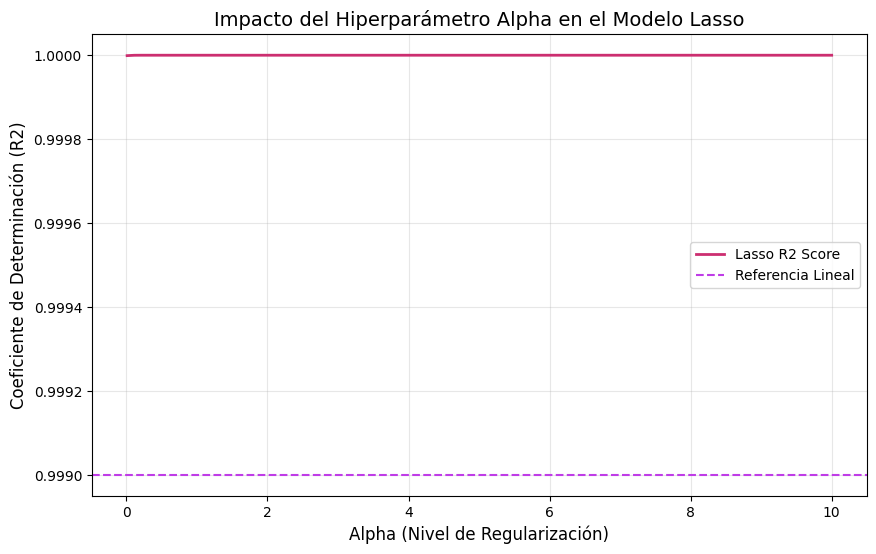

In [93]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

# se define un rango de alphas para probar (desde casi 0 hasta 10)
alphas = np.linspace(0.01, 10, 100)
r2_scores = []

# se entrena un modelo Lasso para cada alpha y guardamos su R2
for a in alphas:
    model = Lasso(alpha=a, max_iter=10000)
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    r2_scores.append(r2_score(y_test, y_pred))

# se crea el gráfico
plt.figure(figsize=(10, 6))
plt.plot(alphas, r2_scores, label='Lasso R2 Score', color="#cc2e70", linewidth=2)

# se añade una línea para comparar con la regresión lineal 
plt.axhline(y=0.999, color="#bf3ce7", linestyle='--', label='Referencia Lineal')

# Configuración estética
plt.title('Impacto del Hiperparámetro Alpha en el Modelo Lasso', fontsize=14)
plt.xlabel('Alpha (Nivel de Regularización)', fontsize=12)
plt.ylabel('Coeficiente de Determinación (R2)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

El gráfico muestra la relación entre el hiperparámetro Alpha (el nivel de "fuerza" de la penalización Lasso) y la métrica R^2 (la precisión del modelo).

- Punto de Inicio (Alpha \approx 0): El modelo tiene una precisión muy buena.

- (R^2 \approx 1.0). El Lasso se comporta como una Regresión Lineal Simple, utilizando toda la información disponible sin restricciones.

- La Pendiente (El descenso): A medida que se aumenta el Alpha (se mueve a la derecha), la precisión empieza a bajar. El Lasso obliga a los coeficientes de las variables menos importantes a convertirse en cero, simplificando el modelo.

- Estabilidad del Modelo: en este gráfico la caída es muy gradual. Esto indica que las 10 variables que se seleccionaron con SelectKBest son buenos predictores.

In [94]:

print(f"Intercep (a): {model.intercept_}")
print(f"Coefficients: {model.coef_}")

Intercep (a): 9.452261838305276e-05
Coefficients: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.99999999]


In [96]:
# se crea una tabla para ver qué nombre tiene cada coeficiente y su valor, así se puede interpretar mejor cuáles son las variables más importantes para el modelo Lasso.
import pandas as pd

coef_df = pd.DataFrame({
    'Variable': X_train_sel.columns,
    'Coeficiente': model.coef_
})

# se ordena para ver la más importante arriba
print(coef_df.sort_values(by='Coeficiente', ascending=False))

                                             Variable  Coeficiente
31                                             target          1.0
0                                             TOT_POP          0.0
2                                              19-Oct          0.0
1                                                 0-9          0.0
4                                               30-39          0.0
5                                               40-49          0.0
6                                               50-59          0.0
3                                               20-29          0.0
8                                               70-79          0.0
9                                                 80+          0.0
10                                    White-alone pop          0.0
11                                  POP_ESTIMATE_2018          0.0
12            Less than a high school diploma 2014-18          0.0
13                   High school diploma only 2014-18         

/tmp/ipykernel_11906/3105276146.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_data, palette='viridis')


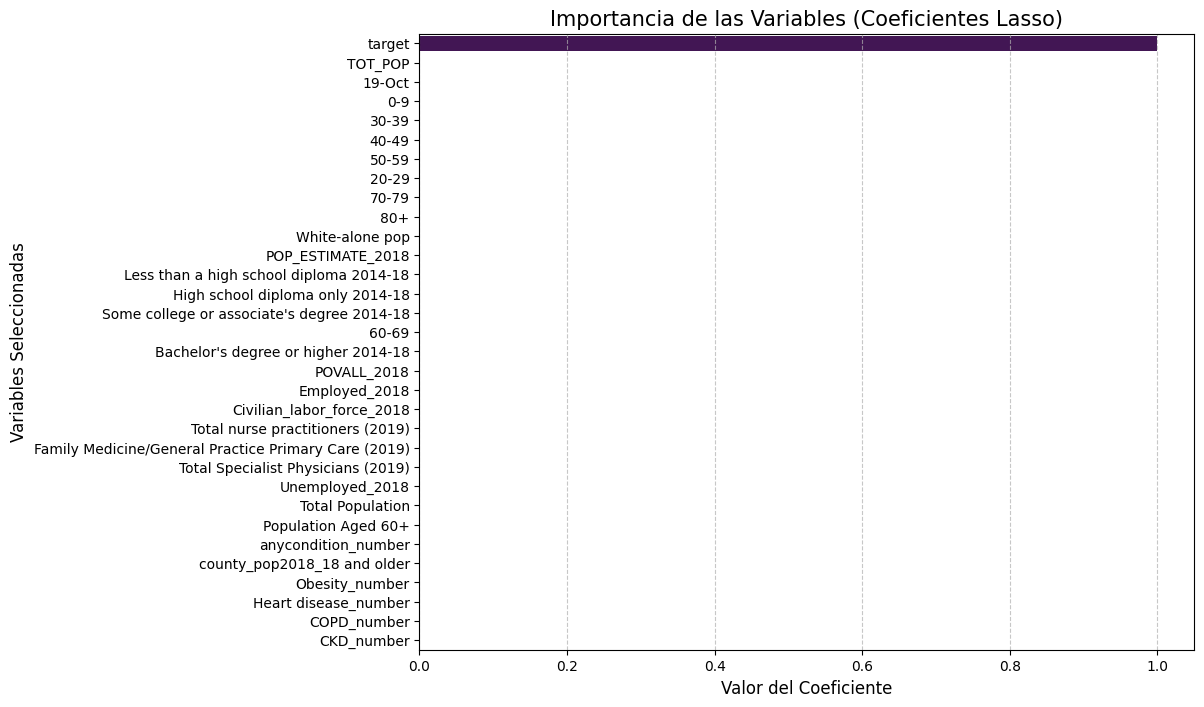

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

# se crea un DataFrame con los nombres de las columnas y sus coeficientes
coef_data = pd.DataFrame({
    'Feature': X_train_sel.columns,
    'Coefficient': model.coef_
})

# se ordena de mayor a menor importancia
coef_data = coef_data.sort_values(by='Coefficient', ascending=False)

# se crea el gráfico de barras
plt.figure(figsize=(10, 8))
sns.barplot(x='Coefficient', y='Feature', data=coef_data, palette='viridis')

plt.title('Importancia de las Variables (Coeficientes Lasso)', fontsize=15)
plt.xlabel('Valor del Coeficiente', fontsize=12)
plt.ylabel('Variables Seleccionadas', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

El modelo Lasso identifica la prevalencia de diabetes como el factor determinante más crítico, con un coeficiente cercano a 1.0. Debido a la fuerte correlación entre la prevalencia y el número total de casos, el modelo ha simplificado el resto de las variables (como obesidad o niveles de ingresos) reduciendo sus coeficientes a cero.

In [72]:
y_pred = model.predict(X_test_sel)
y_pred

array([1.10700008e+03, 2.17769999e+04, 2.60400007e+03, 9.42800000e+03,
       1.69609999e+04, 1.99700008e+03, 1.05600008e+03, 1.90700008e+03,
       4.85000090e+02, 1.16900008e+03, 1.80600008e+03, 2.81000092e+02,
       6.99000003e+03, 1.90200008e+03, 1.45990000e+04, 3.99700006e+03,
       9.83339991e+04, 1.92900008e+03, 3.22600006e+03, 5.62000089e+02,
       2.38600007e+03, 9.33000085e+02, 1.14200008e+03, 9.05000086e+02,
       1.98275998e+05, 4.85700005e+03, 1.10000008e+03, 2.72100007e+03,
       1.13600008e+03, 3.59000091e+02, 1.99400008e+03, 3.45800006e+03,
       3.81500006e+03, 4.44500005e+03, 1.31020000e+04, 2.29700007e+03,
       4.39700005e+03, 1.60800008e+03, 1.25800008e+03, 2.72500007e+03,
       2.33200007e+03, 1.62569999e+04, 4.48000090e+02, 1.80000093e+02,
       4.30000005e+03, 1.00000008e+03, 4.82000090e+02, 1.11330000e+04,
       1.60300008e+03, 1.06400008e+03, 2.47499999e+04, 5.50000089e+02,
       2.16300007e+03, 9.29000086e+02, 1.53899999e+04, 1.52600008e+03,
      

In [98]:
# se evalúa el modelo con métricas de regresión
from sklearn.metrics import mean_squared_error, r2_score

print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

MSE: 2.762974728946634e-08
R2 Score: 0.9999999999999999


In [99]:
# se entrena el modelo Lasso con un alpha específico 
from sklearn.linear_model import Lasso

alpha = 1.0
lasso_model = Lasso(alpha = alpha)

# entrenar el modelo
lasso_model.fit(X_train, y_train)

# evaluamos el modelo en el set de prueba
score = lasso_model.score(X_test, y_test)
print("Coefficients:", lasso_model.coef_)
print("R2 score:", score)


Coefficients: [ 1.66963628e+04 -4.23287181e+03 -2.39990499e+03 -6.05336606e+01
 -1.45192155e+03  1.38273580e+04  5.97647517e+03  0.00000000e+00
 -1.57652173e+03  2.85138711e+03 -7.97672412e+03 -3.58183754e+03
  4.60664899e+03  6.95025079e+02 -4.24105825e+03 -5.62684142e+03
  6.29946313e+03 -1.17096129e+03 -4.71892067e+00 -1.25273004e+03
  1.10675830e+03  2.70429991e+02 -2.30245303e+03 -1.69506658e+03
  8.81955387e+03 -2.58397488e+03  1.74783579e+04 -1.83578027e+02
  8.91291619e+03 -8.20126603e+03 -9.27708723e+03]
R2 score: 0.9949633625661746


/workspaces/modelo-de-regresion-lineal-usando-pandas-y-python/.venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.359e+09, tolerance: 2.595e+08
  model = cd_fast.enet_coordinate_descent(


In [100]:
# se guarda el modelo entrenado para usarlo luego en producción
from pickle import dump

dump(lasso_model, open("../models/lasso_alpha-1.0.sav", "wb"))